# Exercise: Predict Diabetes with a Linear Regression Model

In this exercise, we'll predict a patient's diabetes desease progression from different health indicators such as body mass index, age, blood pressure etc. 

Your tasks are the following:

- Get an overview of the dataset
- Plot a histogram of the data
- Plot the correlation matrix
- Split into training and test data
- Train a linear regression model
- Evaluate the model and plot the results

## 1. Data Analysis

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

**TODO**: Load in the diabetes dataset from scikit-learn and get familiar with the dataset, here is the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html). Find out these basic properties:

- How many samples does the dataset have?
- How many features does the dataset have?
- Are there any null values that we have to take care of?
- Has the data been standardized already or do we have to take care of this?
- Does the dataset contain numerical or categorical values or both?

In [2]:
# TODO: YOUR CODE GOES HERE
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes.target

In [3]:
df_diabetes.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [4]:
df_diabetes.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


**YOUR ANSWER**:

**TODO**: Plot a histogram in matplotlib to get an overview of the data.

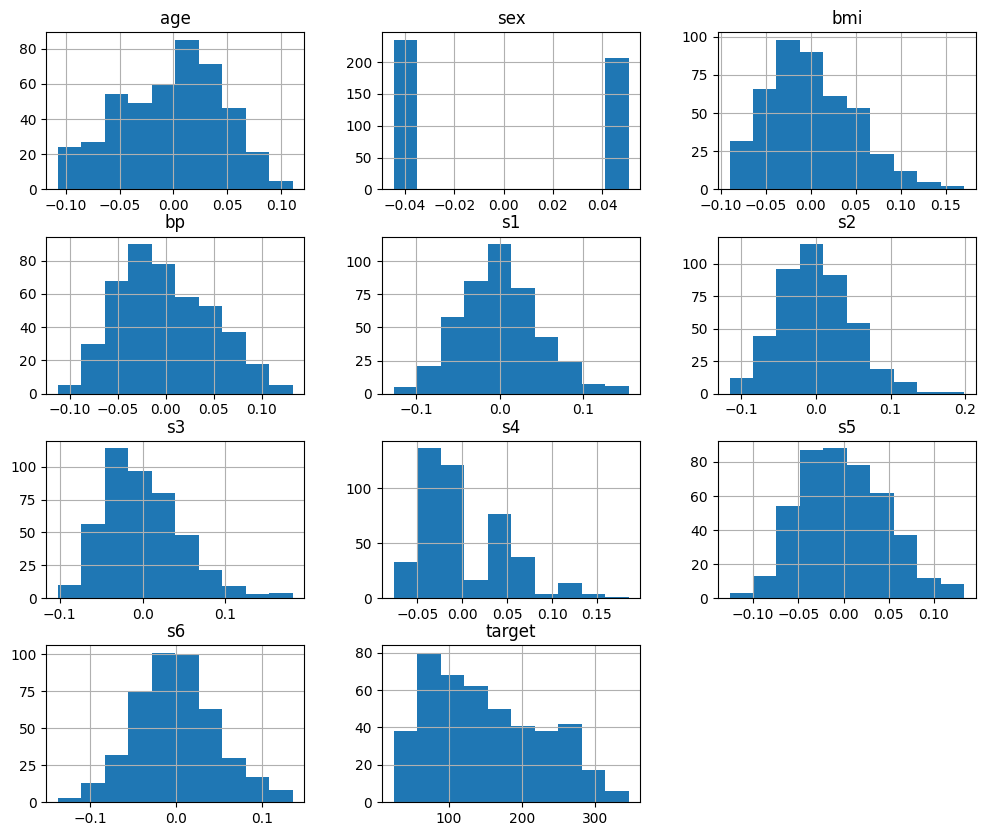

In [5]:
df_diabetes.hist(figsize=(12, 10))
plt.show()

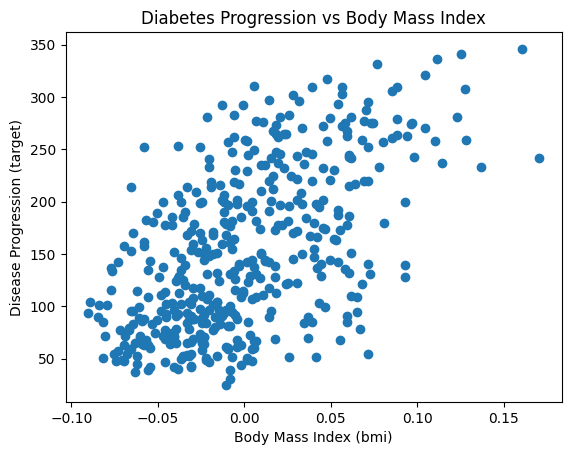

In [6]:
# TODO: YOUR CODE GOES HERE
plt.scatter(df_diabetes['bmi'], df_diabetes['target'])
plt.xlabel('Body Mass Index (bmi)')
plt.ylabel('Disease Progression (target)')
plt.title('Diabetes Progression vs Body Mass Index')
plt.show()

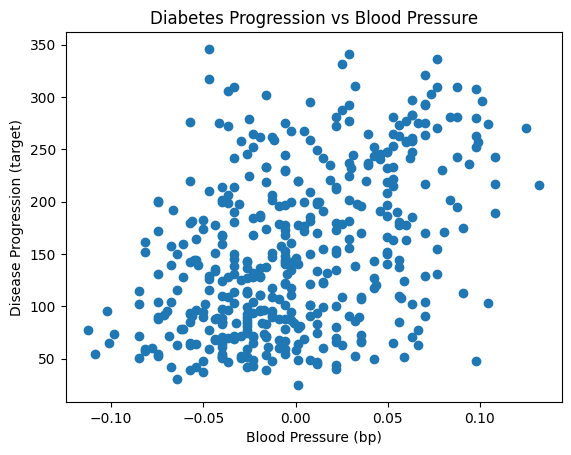

In [7]:
plt.scatter(df_diabetes['bp'], df_diabetes['target'])
plt.xlabel('Blood Pressure (bp)')
plt.ylabel('Disease Progression (target)')
plt.title('Diabetes Progression vs Blood Pressure')
plt.show()

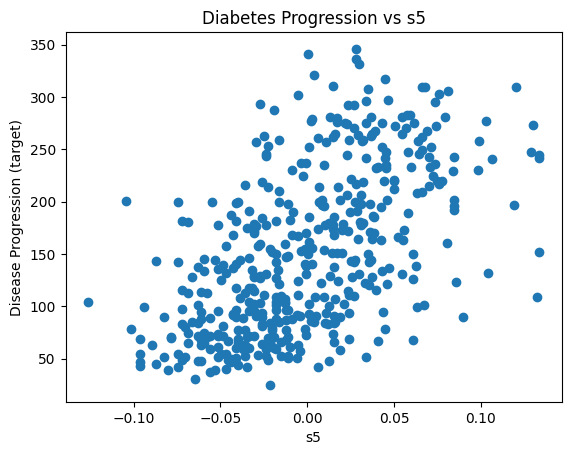

In [8]:
plt.scatter(df_diabetes['s5'], df_diabetes['target'])
plt.xlabel('s5')
plt.ylabel('Disease Progression (target)')
plt.title('Diabetes Progression vs s5')
plt.show()

**TODO**: Calculate the linear correlation matrix of the features and the target and plot the results. Which feature is the most important for our prediction goal?

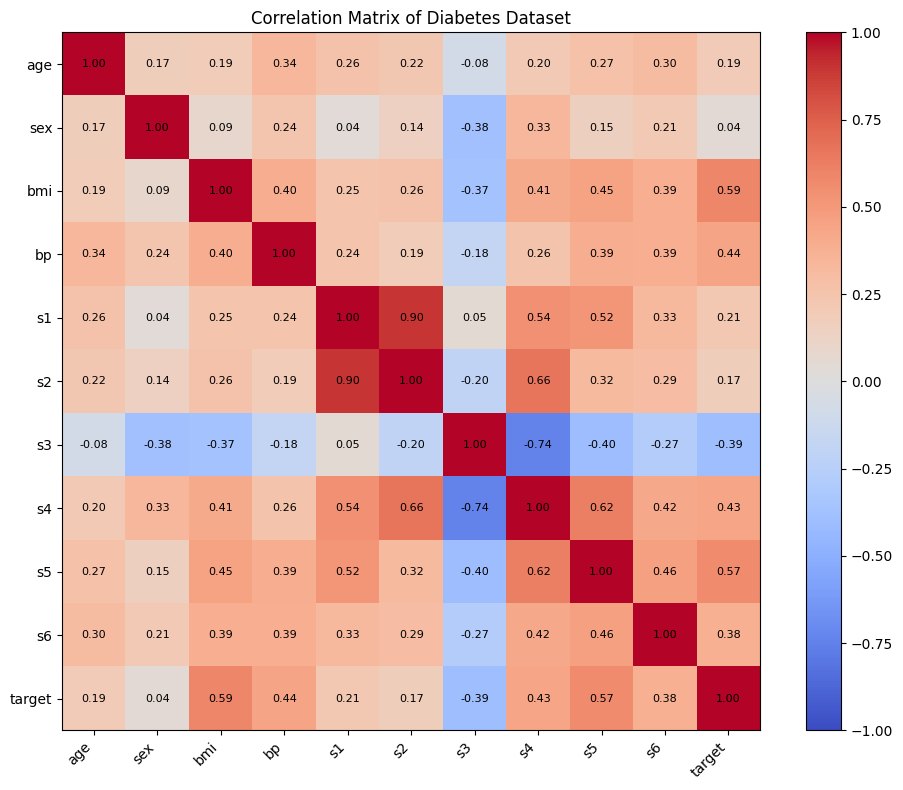

In [9]:
# TODO: YOUR CODE GOES HERE
correlation_matrix = df_diabetes.corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation_matrix.columns)
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation Matrix of Diabetes Dataset')
plt.tight_layout()
plt.show()


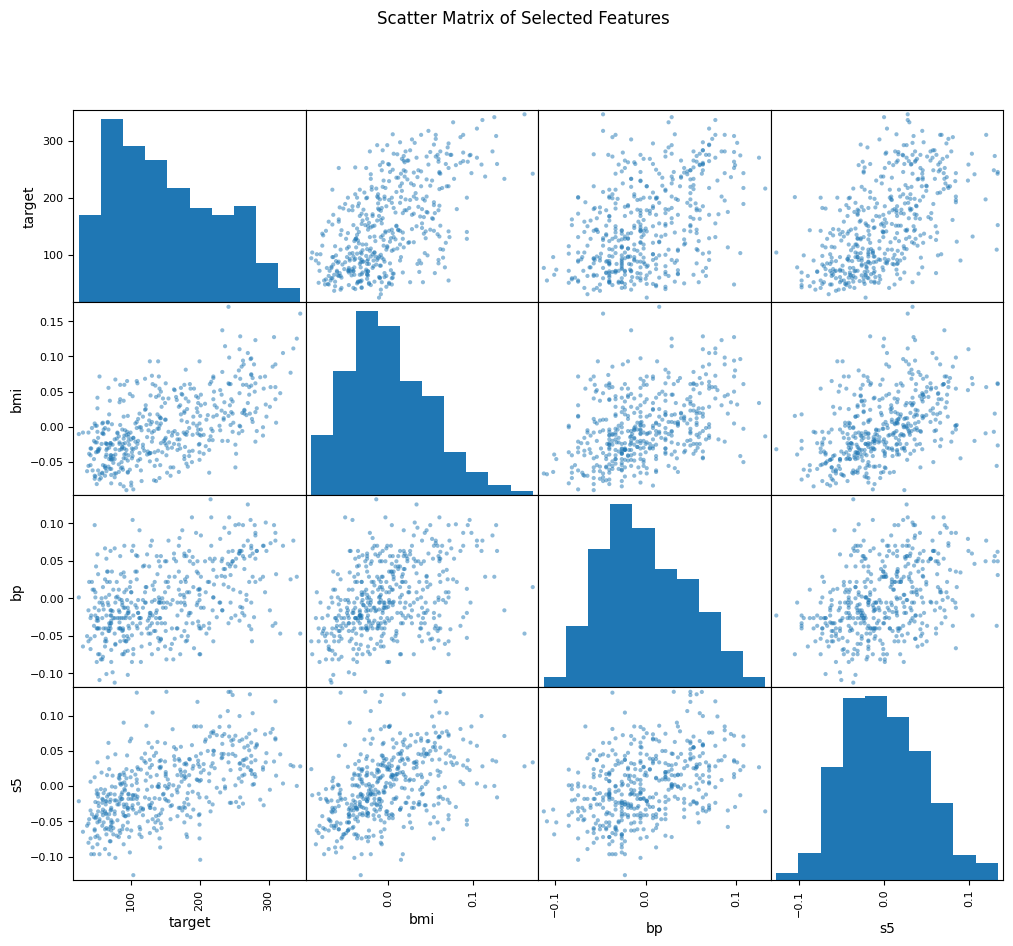

In [10]:
features = ['target', 'bmi', 'bp', 's5']

scatter_matrix = pd.plotting.scatter_matrix(df_diabetes[features], figsize=(12, 10))
plt.suptitle('Scatter Matrix of Selected Features')
plt.show()

**YOUR ANSWER**: Based on the correlation matrix, the feature 'bmi' has the highest correlation with the target variable, indicating that it is the most important feature for predicting diabetes progression in this dataset.

## 2. Training and Evaluation

**TODO**: Store the features and labels in dataframes called `X` and `y`, respectively. Create a train and test split with 80% training data and 20% test data.

In [11]:
# TODO: YOUR CODE GOES HERE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_diabetes.drop(columns='target'), df_diabetes['target'], test_size=0.2, random_state=42)

**TODO**: Create and train a linear regression model.

In [12]:
# TODO: YOUR CODE GOES HERE
from sklearn.linear_model import LinearRegression 
import numpy as np

ln = LinearRegression()
ln.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**TODO**: Evaluate the model on the test dataset: make predictions and calculate the RMSE.

In [13]:
# TODO: YOUR CODE GOES HERE

y_pred = ln.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Root Mean Squared Error (RMSE) on test set: {rmse:.3f}")


Root Mean Squared Error (RMSE) on test set: 53.853


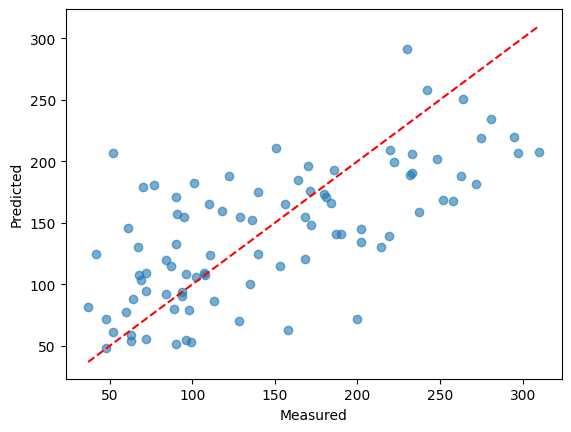

In [14]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel('Measured'); plt.ylabel('Predicted'); plt.show()

**TODO**: Train a simple linear regression model with only the most important feature for comparison and plot the predictions and the measurements. Do you think we have found a reasonable model according to the plot?

In [15]:
# TODO: YOUR CODE GOES HERE

ln.fit(X_train[['bmi']], y_train)
y_pred = ln.predict(X_test[['bmi']])
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Root Mean Squared Error (RMSE) on test set: {rmse:.3f}")

Root Mean Squared Error (RMSE) on test set: 63.732


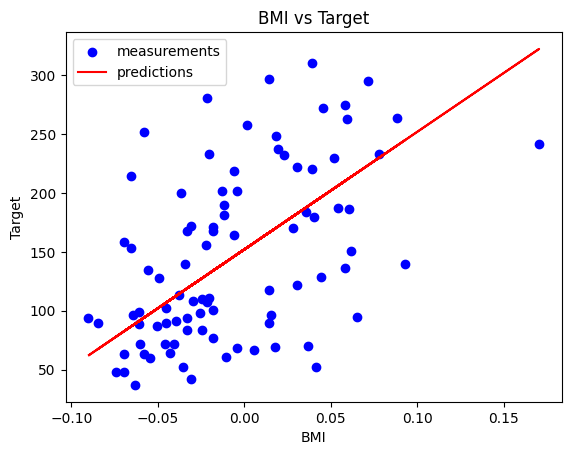

In [16]:
plt.scatter(X_test['bmi'], y_test, color='blue', label='measurements')
plt.plot(X_test['bmi'], y_pred, color='red', label='predictions')
plt.xlabel('BMI')
plt.ylabel('Target')
plt.title('BMI vs Target')
plt.legend()
plt.show()

**YOUR ANSWER**:

- **RMSE (full model, all features):** 53.853
- **RMSE (bmi only):** 63.732

**Short interpretation:** Lower RMSE indicates better accuracy. The model with all features has the lowest RMSE (≈53.9), therefore predicting with less error than using only `bmi` (≈63.7). Although `bmi` has the highest individual correlation with `target`, the combination of multiple features improves predictive performance. Interpret RMSE differences in the context of the `target` unit and check for generalization with cross-validation or regularization.